In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])

    return u



print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_run5/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [4]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.537553  ,  0.642705  ,  0.549253  ,  0.373063  ,  0.397031  ],
        [ 0.53756087,  0.64271595,  0.54924315,  0.37305137,  0.39704231],
        [ 0.53754599,  0.64269731,  0.54925608,  0.37305516,  0.39702619],
        ...,
        [ 1.20608949, -0.25434776,  0.57542001,  0.24903674,  0.48970968],
        [ 0.04951041,  0.36606468,  0.35618044,  0.1986485 ,  0.83854278],
        [ 1.18209722,  0.50818933,  0.68326058,  0.71976992,  0.51419814]],
       shape=(100000, 5))]

In [5]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([2.02502927, 2.02448539, 2.01759835, ...,       -inf, 0.00255886,
              -inf], shape=(100000,))]

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))

# maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))


In [7]:
maxld_pt1

array([[6.02832769, 1.12342321, 0.68014536, 9.13980132, 0.31828089]])

In [8]:
log_density(maxld_pt1)

array([2.78171095])

In [9]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [10]:
gwf.rhostat(h_pt1)

array(5.55759873)

In [11]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(3.54000496), array(0.01055448))

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

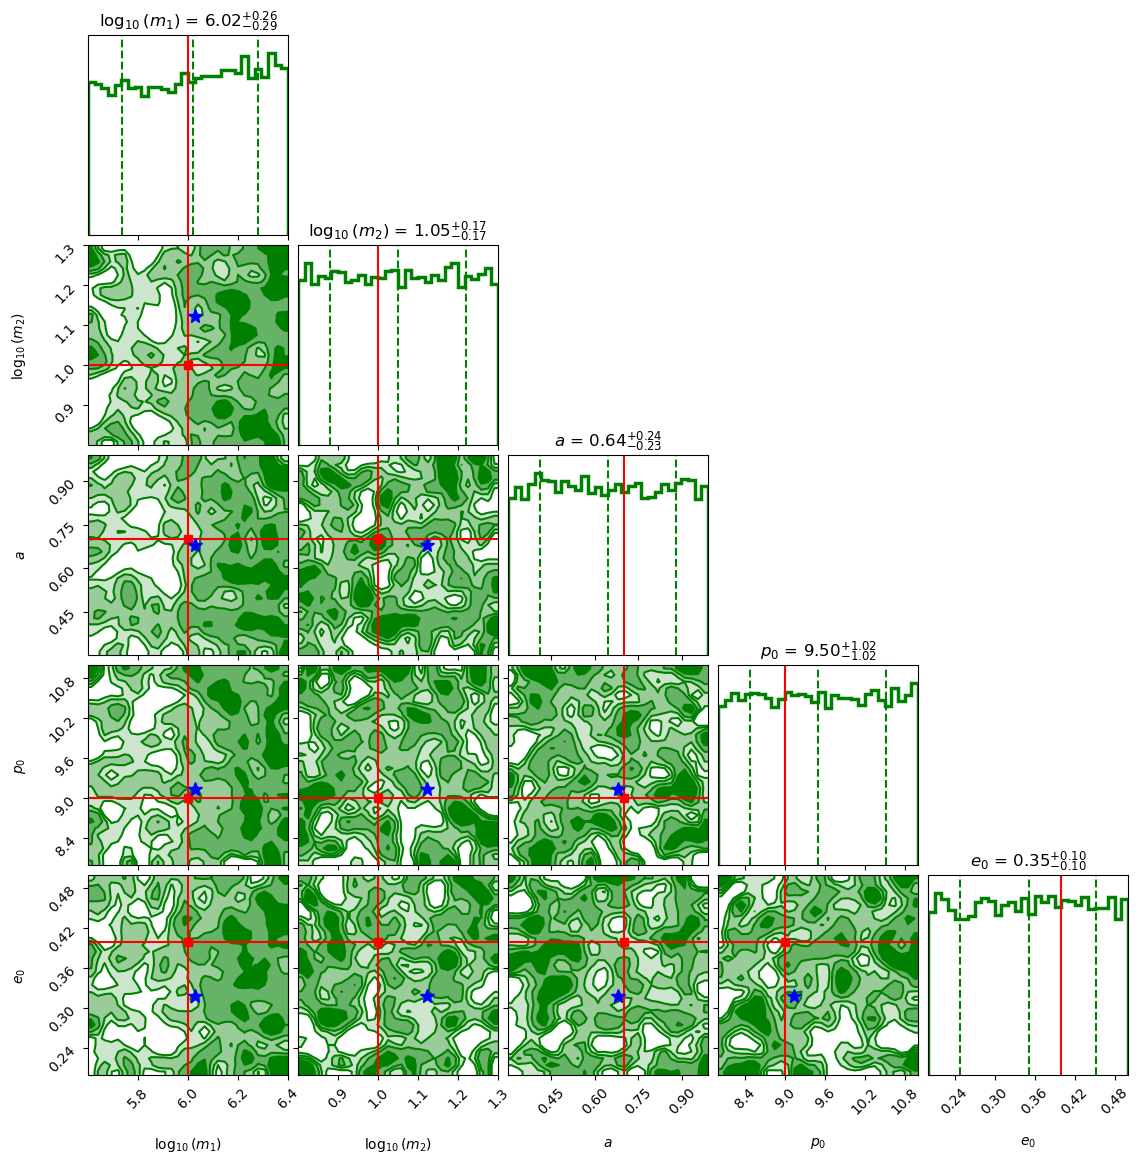

In [13]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




# connection plot

In [14]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [15]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.02832769, 1.12342321, 0.68014536, 9.13980132, 0.31828089]])

In [16]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
# n_points = 50
# t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
# line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]

#NOTE: extended plots till it hits prior boundaries

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]



In [17]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [18]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
logden_theory_proc1

array([0.09730791, 0.09032748, 0.10439832, 0.12259479, 0.12574368,
       0.1369991 , 0.13426494, 0.15589567, 0.16700149, 0.1929241 ,
       0.21237783, 0.25738356, 0.27276398, 0.35262723, 0.54734083,
       0.86148087, 1.27938776, 1.86139114, 2.23703208, 2.807724  ,
       2.3594333 , 2.02449846, 1.65869208, 1.29436038, 1.1508786 ,
       1.0322799 , 0.96319049, 0.92883043, 0.93488867, 1.0287014 ,
       1.26879419, 1.86824812, 4.23831218, 4.82003611, 1.69341115,
       0.9795499 , 0.70188038, 0.54864668, 0.46731149, 0.38368104,
       0.36911253, 0.31899584, 0.27100966, 0.23406797, 0.24114115,
       0.22172485, 0.19437241, 0.17512367, 0.18119942, 0.17598754])

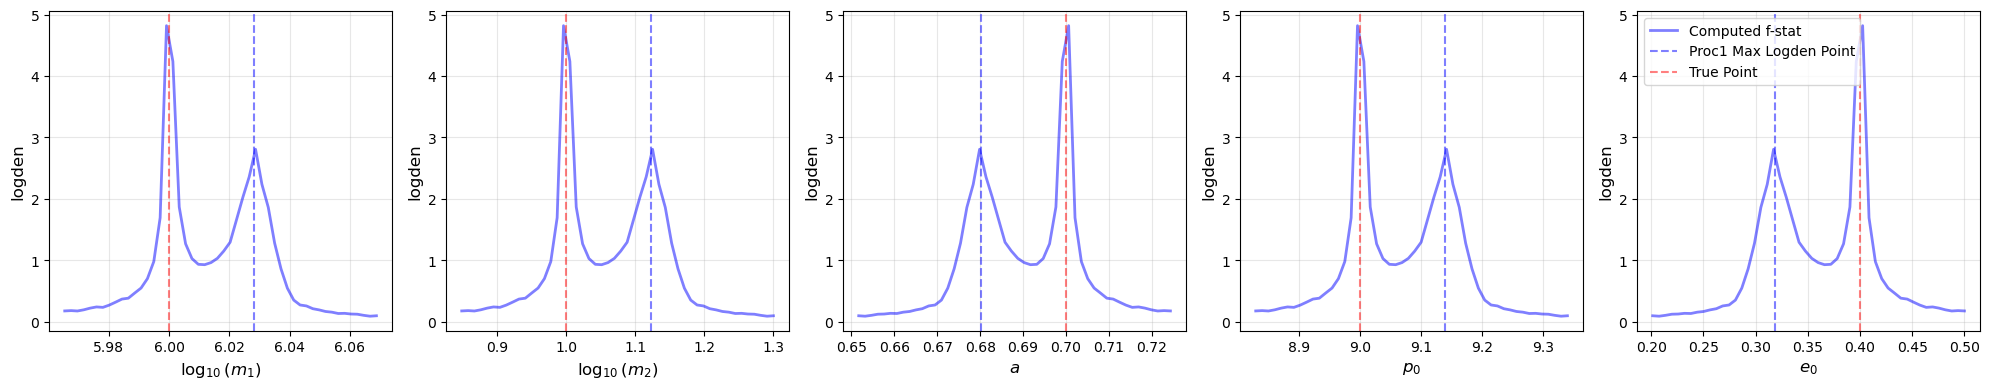

In [19]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [20]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [21]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat_timemax(data, template)
    X_proc1.append(X.get())

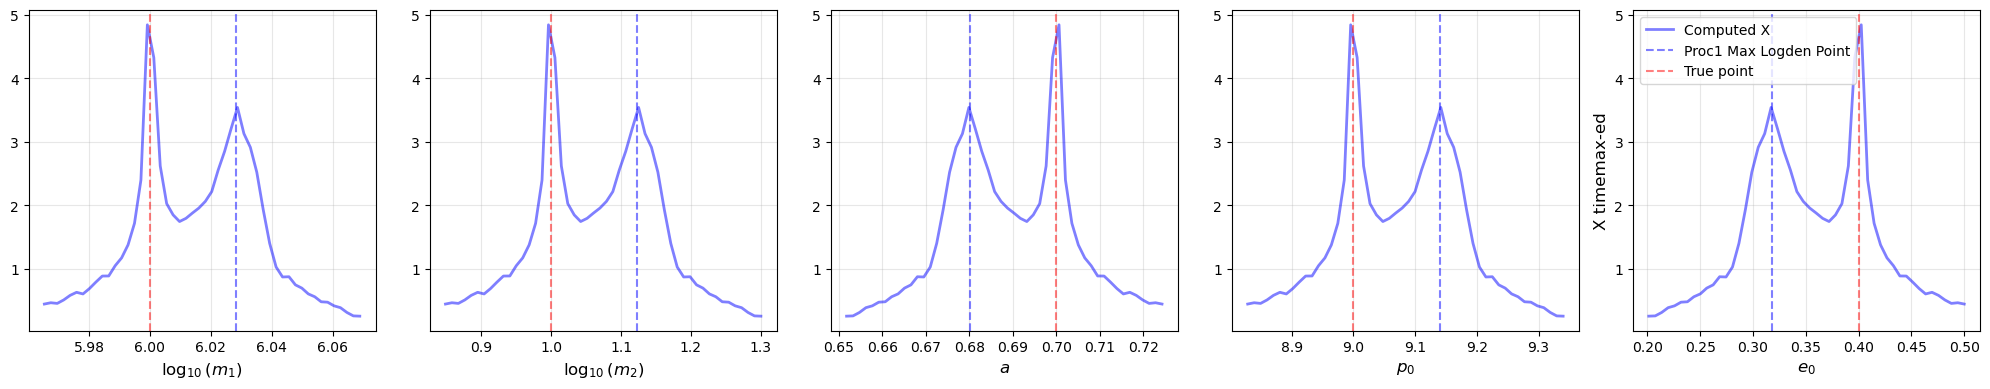

In [22]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [23]:
X_proc1_nont = []
for template in templates_proc1:
    X = gwf.Xstat(data, template)
    X_proc1_nont.append(X.get())

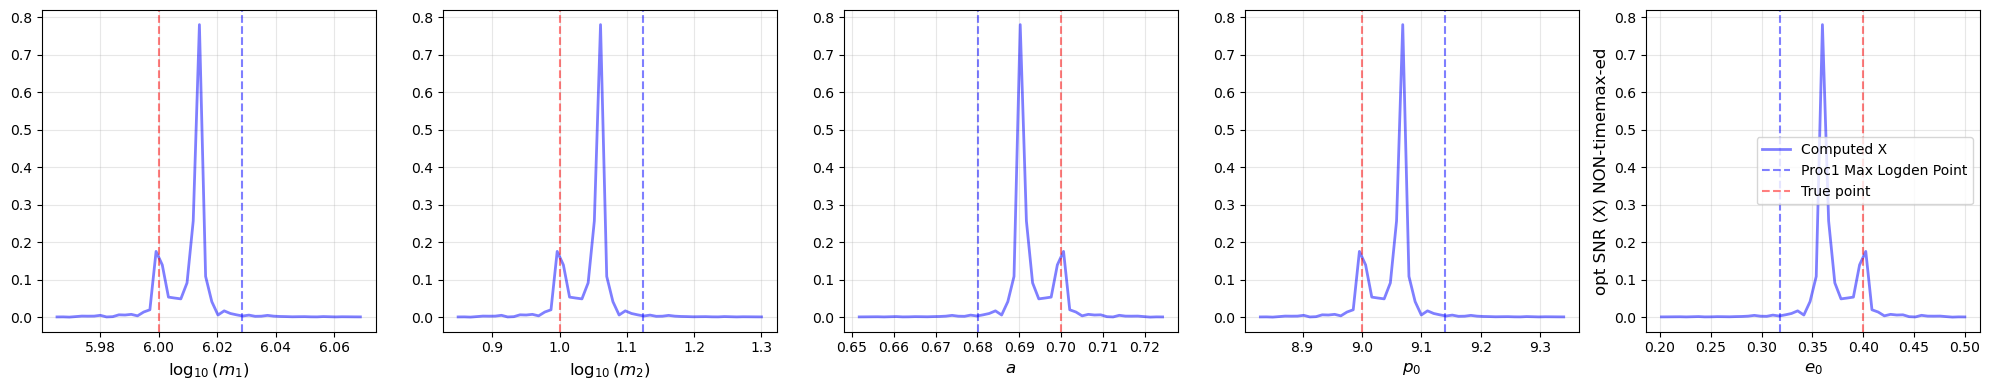

In [24]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X) NON-timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_nont, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [25]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP (not combined)
    waveforms_per_group = []
    for group in groups:
        mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
                                          qS, phiS, qK, phiK, 
                                          Phi_phi0, Phi_theta0, Phi_r0,
                                          dt=dt, T=T,
                                          mode_selection=group,  # Pass group list
                                          include_minus_mkn=False)
        # Sum all modes within this group
        mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form_summed)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [26]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf.rhostat_modes(hm_arr.T))

In [27]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf.Xmstat_timemax(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)

In [28]:
chi2_proc1 = []
for i in range(len(mode_forms)):
    chi2 = gwf.chi_sq(Xm_proc1[i], rhostats_proc1[i])
    chi2_proc1.append(chi2.get())

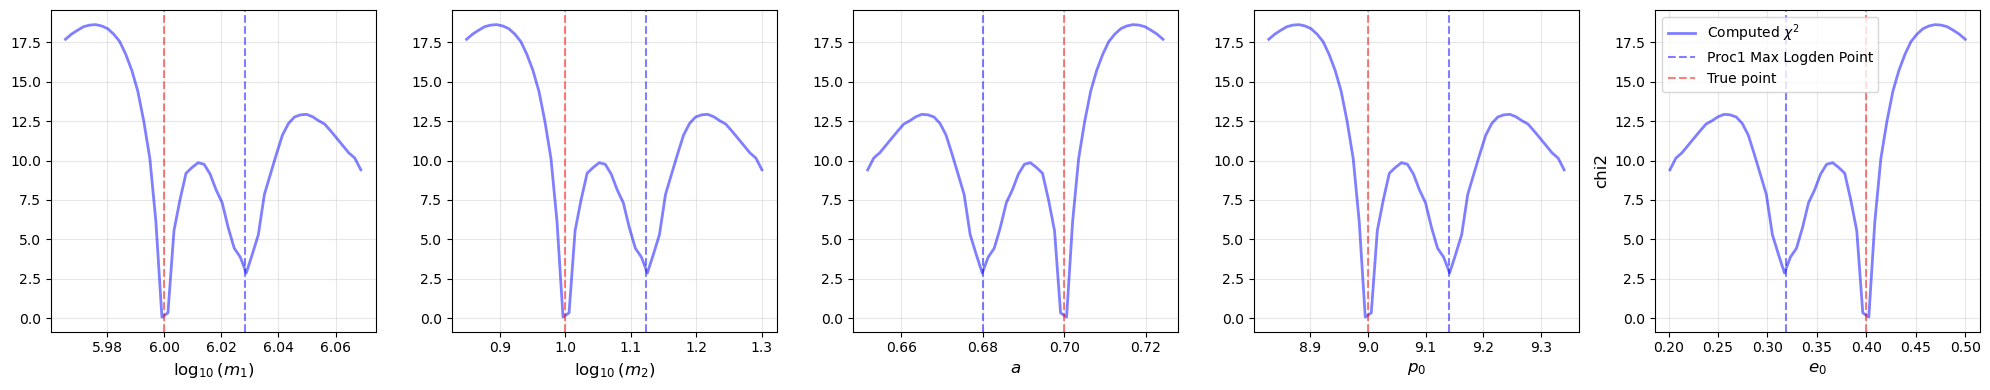

In [29]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label=r'Computed $\chi^2$')
    # ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()


In [30]:
betas_proc1 = []
for rho_arr in rhostats_proc1:
    rho_tot = np.sqrt(np.sum(rho_arr**2))
    rho_dom_M = np.max(rho_arr)
    beta = gwf.calc_beta(rho_dom_M, rho_tot)
    betas_proc1.append(beta.get())

betas_proc1 = np.array(betas_proc1)

In [31]:
f_theory = []
for i in range(0, 50):
    f_theor = X_proc1[i] * np.exp(-0.5 * betas_proc1[i] * chi2_proc1[i])
    # print(f_theor)
    f_theory.append(f_theor)

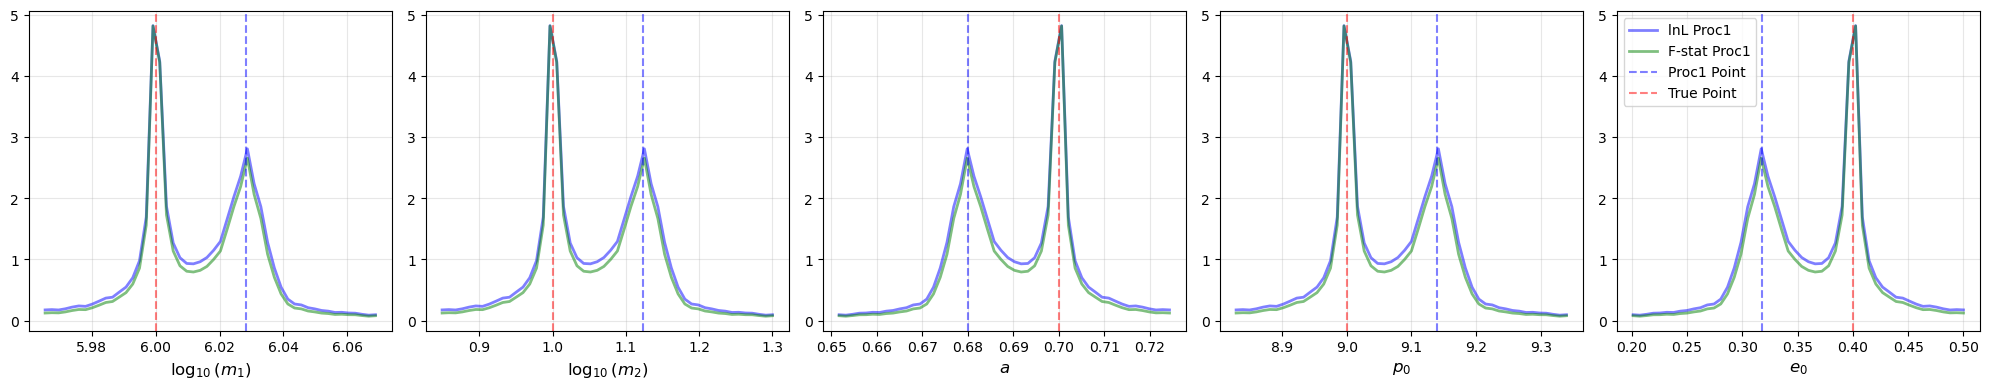

In [32]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
for dim in range(5):
    ax = axs_1d[dim]

    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-',
            color='blue', alpha=0.5, linewidth=2, label='lnL Proc1')
    ax.plot(line_points_proc1[dim], f_theory, '-',
            color='green', alpha=0.5, linewidth=2, label='F-stat Proc1')

    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--',
               alpha=0.5, label='Proc1 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--',
               alpha=0.5, label='True Point')

    ax.set_xlabel(labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()

# extended connection plots w/ first secondary

In [33]:
i = 3  # p0
n_points = 100

# --- Secondary 1 ---
start1     = np.array([5.87693589, 0.85550847, 0.49798554, 10.12743171, 0.48748133])
direction1 = true_pt - start1
t_lo1_all  = np.where(direction1 < 0, (prior_hi - start1)/direction1, (prior_lo - start1)/direction1)
t_hi1_all  = np.where(direction1 < 0, (prior_lo - start1)/direction1, (prior_hi - start1)/direction1)
t_lo1, t_hi1 = np.max(t_lo1_all), np.min(t_hi1_all)
t_vals1    = np.sort(np.unique(np.concatenate([np.linspace(t_lo1, t_hi1, n_points), [0.0, 1.0]])))
line_pts1  = start1[:, np.newaxis] + t_vals1 * direction1[:, np.newaxis]
logden_s1  = log_density(line_pts1.T)

# --- Secondary 2 ---
start2     = np.array([5.93979891, 0.9842598, 0.55618277, 9.82410481, 0.41788778])
direction2 = true_pt - start2
t_lo2_all  = np.where(direction2 < 0, (prior_hi - start2)/direction2, (prior_lo - start2)/direction2)
t_hi2_all  = np.where(direction2 < 0, (prior_lo - start2)/direction2, (prior_hi - start2)/direction2)
t_lo2, t_hi2 = np.max(t_lo2_all), np.min(t_hi2_all)
t_vals2    = np.sort(np.unique(np.concatenate([np.linspace(t_lo2, t_hi2, n_points), [0.0, 1.0]])))
line_pts2  = start2[:, np.newaxis] + t_vals2 * direction2[:, np.newaxis]
logden_s2  = log_density(line_pts2.T)

# --- Secondary 3 ---
start3     = np.array([6.02832769, 1.12342321, 0.68014536, 9.13980132, 0.31828089])
direction3 = true_pt - start3
t_lo3_all  = np.where(direction3 < 0, (prior_hi - start3)/direction3, (prior_lo - start3)/direction3)
t_hi3_all  = np.where(direction3 < 0, (prior_lo - start3)/direction3, (prior_hi - start3)/direction3)
t_lo3, t_hi3 = np.max(t_lo3_all), np.min(t_hi3_all)
t_vals3    = np.sort(np.unique(np.concatenate([np.linspace(t_lo3, t_hi3, n_points), [0.0, 1.0]])))
line_pts3  = start3[:, np.newaxis] + t_vals3 * direction3[:, np.newaxis]
logden_s3  = log_density(line_pts3.T)

In [34]:
def make_log_density(T_val):
    gwf_T = GWfuncs.GravWaveAnalysis(T_val, dt)
    loglike_T = loglike_timemax.LogLikeTimeMax(
        params_star, waveform_gen_comb, gwf_T,
        verbose=False, waveform_gen_sep=waveform_gen_sep,
        ell=ell, n_vals=n_vals, M_mode=None)
    
    print(f"T={T_val:.4f}yr  SNR={gwf_T.rhostat(loglike_T.signal):.3f}")

    def log_density_T(params):
        params = np.asarray(params)
        n_samples = params.shape[0]
        log_likes = np.zeros(n_samples)
        for i in range(n_samples):
            logm1, logm2, a, p0, e0 = params[i]
            log_likes[i] = loglike_T(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        return log_likes

    return log_density_T

In [35]:
make_log_density(1/12)([start1]), make_log_density(1/12)([start2])

T=0.0833yr  SNR=3.330
T=0.0833yr  SNR=3.330


(array([1.95378212]), array([1.90975579]))

In [36]:
make_log_density(3/12)([start1]), make_log_density(3/12)([start2])

T=0.2500yr  SNR=5.942
T=0.2500yr  SNR=5.942


(array([3.44277489]), array([4.5230902]))

In [37]:
make_log_density(6/12)([start1]), make_log_density(6/12)([start2])

T=0.5000yr  SNR=8.808
T=0.5000yr  SNR=8.808


(array([1.35034326]), array([3.09319266]))

In [38]:
make_log_density(12/12)([start1]), make_log_density(12/12)([start2])

T=1.0000yr  SNR=14.081
T=1.0000yr  SNR=14.081


(array([0.3366628]), array([0.93645921]))

In [39]:
make_log_density(24/12)([start1]), make_log_density(24/12)([start2])

T=2.0000yr  SNR=32.866
T=2.0000yr  SNR=32.866


(array([0.06170043]), array([0.13881336]))

In [40]:
T_vals = [1/12, 3/12, 6/12, 12/12, 24/12]  # 1, 3, 6, 12 months
colors = ['purple', 'blue', 'green', 'red', 'orange']


logden_per_T = {}
for T_val in T_vals:
    ld_func = make_log_density(T_val)
    logden_per_T[T_val] = ld_func(line_pts1.T)


T=0.0833yr  SNR=3.330
T=0.2500yr  SNR=5.942
T=0.5000yr  SNR=8.808
T=1.0000yr  SNR=14.081
T=2.0000yr  SNR=32.866


In [41]:
logden_per_T_pt2 = {}
for T_val in T_vals:
    ld_func = make_log_density(T_val)
    logden_per_T_pt2[T_val] = ld_func(line_pts2.T)

T=0.0833yr  SNR=3.330
T=0.2500yr  SNR=5.942
T=0.5000yr  SNR=8.808
T=1.0000yr  SNR=14.081
T=2.0000yr  SNR=32.866


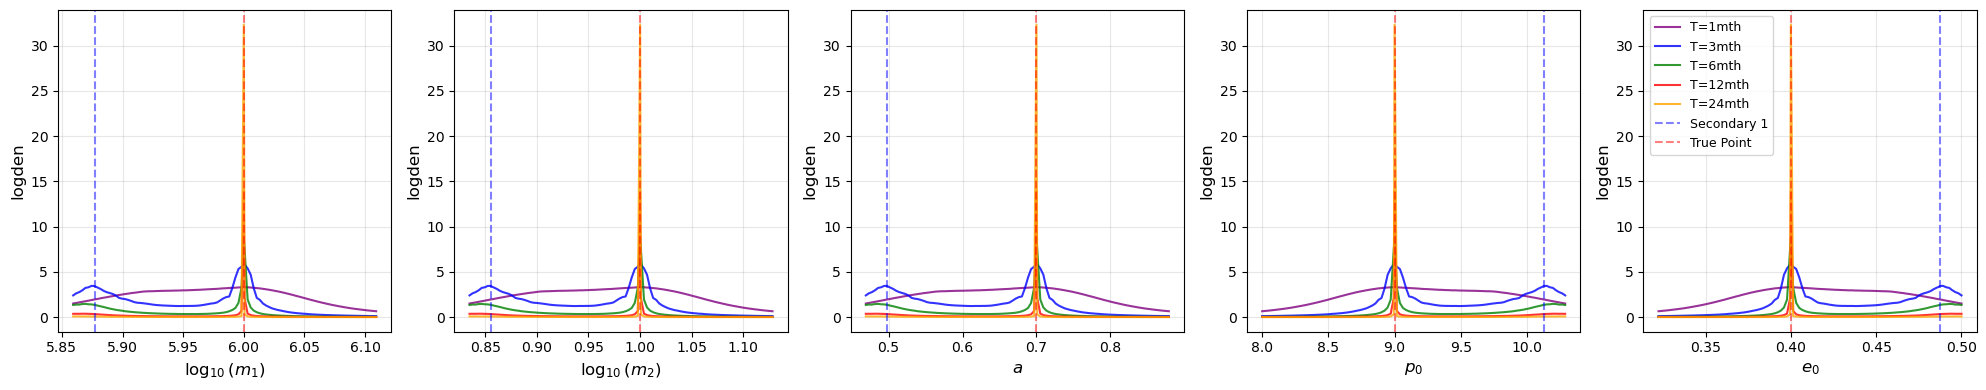

In [42]:
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for dim in range(5):
    ax = axs[dim]
    for T_val, color in zip(T_vals, colors):
        ax.plot(line_pts1[dim], logden_per_T[T_val], '-',
                color=color, alpha=0.8, linewidth=1.5, label=f'T={T_val*12:.0f}mth')
    ax.axvline(start1[dim], color='blue', linestyle='--', alpha=0.5, label='Secondary 1')
    ax.axvline(param_true[dim],        color='red',  linestyle='--', alpha=0.5, label='True Point')
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

axs[-1].legend(fontsize=9)
plt.tight_layout()

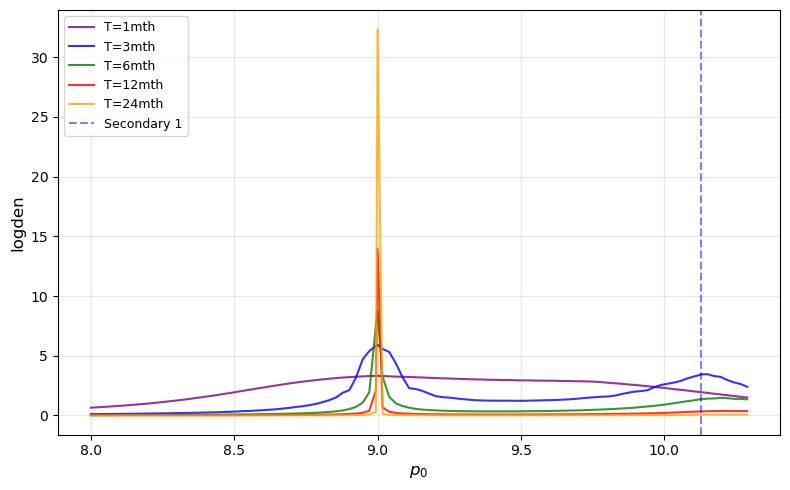

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))

for T_val, color in zip(T_vals, colors):
    ax.plot(line_pts1[3], logden_per_T[T_val], '-',
            color=color, alpha=0.8, linewidth=1.5, label=f'T={T_val*12:.0f}mth')

ax.axvline(start1[3],     color='blue', linestyle='--', alpha=0.5, label='Secondary 1')
# ax.axvline(param_true[3], color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

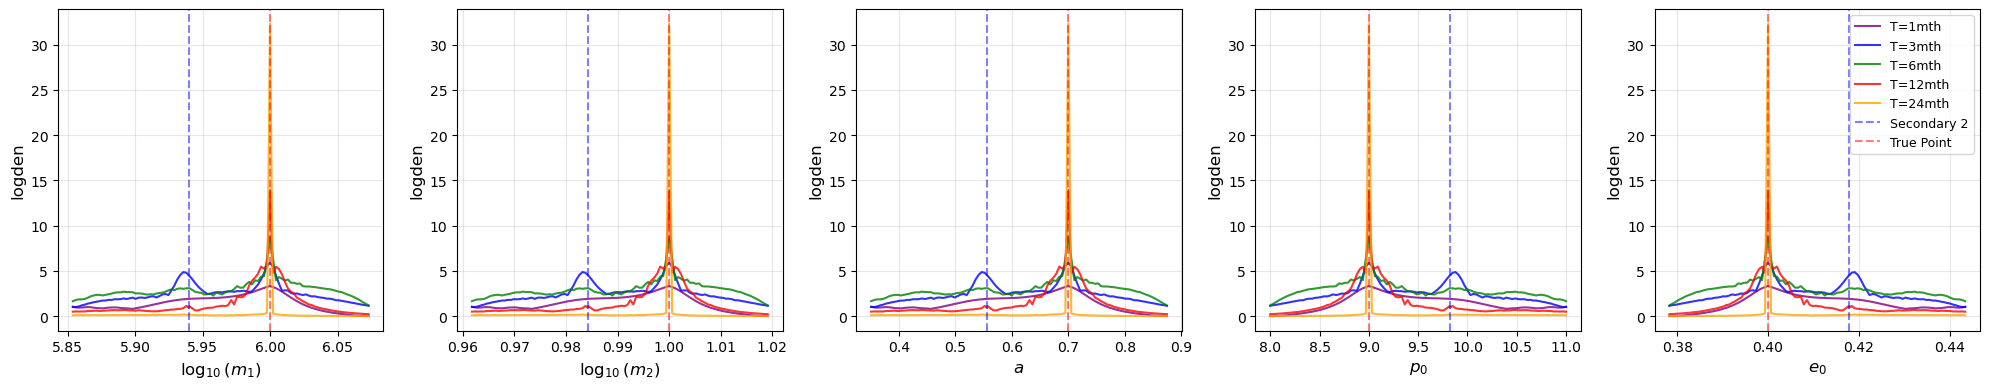

In [43]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for dim in range(5):
    ax = axs[dim]
    for T_val, color in zip(T_vals, colors):
        ax.plot(line_pts2[dim], logden_per_T_pt2[T_val], '-',
                color=color, alpha=0.8, linewidth=1.5, label=f'T={T_val*12:.0f}mth')
    ax.axvline(start2[dim], color='blue', linestyle='--', alpha=0.5, label='Secondary 2')
    ax.axvline(param_true[dim],        color='red',  linestyle='--', alpha=0.5, label='True Point')
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

axs[-1].legend(fontsize=9)
plt.tight_layout()

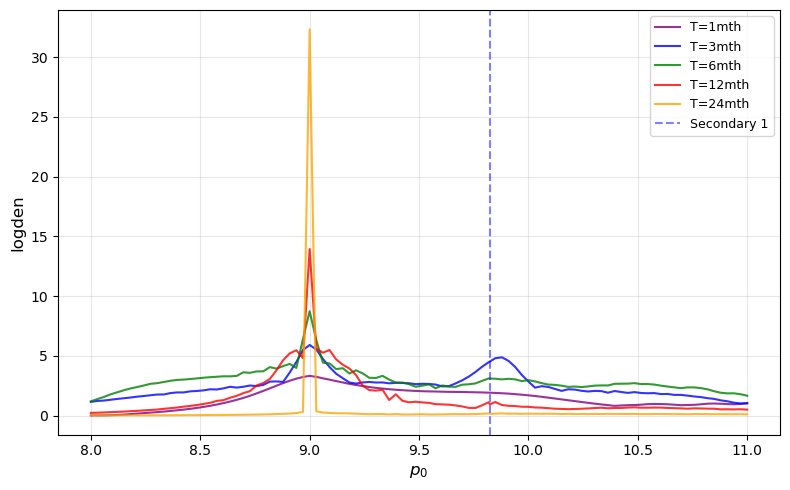

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

for T_val, color in zip(T_vals, colors):
    ax.plot(line_pts2[3], logden_per_T_pt2[T_val], '-',
            color=color, alpha=0.8, linewidth=1.5, label=f'T={T_val*12:.0f}mth')

ax.axvline(start2[3],     color='blue', linestyle='--', alpha=0.5, label='Secondary 1')
# ax.axvline(param_true[3], color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [ ]:
def make_log_density(T_val):
    gwf_T = GWfuncs.GravWaveAnalysis(T_val, dt)
    loglike_T = loglike_timemax.LogLikeTimeMax(
        params_star, waveform_gen_comb, gwf_T,
        verbose=False, waveform_gen_sep=waveform_gen_sep,
        ell=ell, n_vals=n_vals, M_mode=None)
    
    print(f"T={T_val:.4f}yr  SNR={gwf_T.rhostat(loglike_T.signal):.3f}")

    def log_density_T(params):
        params = np.asarray(params)
        n_samples = params.shape[0]
        log_likes = np.zeros(n_samples)
        for i in range(n_samples):
            logm1, logm2, a, p0, e0 = params[i]
            log_likes[i] = loglike_T(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        return log_likes

    return log_density_T

In [ ]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_pts1[3], logden_p0_s1, '-', color='blue',   linewidth=2, label='Secondary 1')
ax.plot(line_pts2[3], logden_p0_s2, '-', color='orange', linewidth=2, label='Secondary 2')
# ax.plot(line_pts3[3], logden_p0_s3, '-', color='green',  linewidth=2, label='Secondary 3')
ax.axvline(start1[3],      color='blue',   linestyle='--', alpha=0.5)
ax.axvline(start2[3],      color='orange', linestyle='--', alpha=0.5)
# ax.axvline(start3[3],      color='green',  linestyle='--', alpha=0.5)
ax.axvline(param_true[3],  color='red',    linestyle='--', alpha=0.7, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()